# What a protein binds, from its sequence — and why edit distance can't see it

What a protein binds is written in its sequence, but not *spread across* it: a **zinc finger** grips
Zn²⁺ with a compact cysteine/histidine cage (the C2H2 motif), a **P-loop ATPase** cradles ATP with the
Walker-A motif `GxxxxGK[S/T]`, a **DNA-binder** clamps the backbone with a short basic patch. The
binding determinant is a **motif plus a compositional bias** — a few residues out of hundreds.

That is exactly why the obvious baseline fails. **Edit (Levenshtein) distance** — the workhorse behind
sequence alignment — compares proteins as whole strings, so a short binding motif is a needle in a
haystack of otherwise-random residues. Two zinc fingers that bind the same ion look almost as
sequence-distant as a zinc finger and a lipid pocket.

`mixle`'s embedding tools instead read a **heterogeneous, binding-relevant record** — metal-coordination
propensity, basic fraction, hydropathy, length, and the detected motif — and recover *what each protein
binds*. This notebook runs the two head to head, then uses the winning map to show the new mixle 0.7.0
hvis tools `goals` and `embedding_health`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import io, re
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from mixle.utils.hvis import htsne, humap

AA = "ACDEFGHIKLMNPQRSTVWY"
KD = dict(zip(AA, [1.8, 2.5, -3.5, -3.5, 2.8, -0.4, -3.2, 4.5, -3.9, 3.8,
                   1.9, -3.5, -1.6, -3.5, -4.5, -0.8, -0.7, 4.2, -0.9, -1.3]))

def profile(boosts):
    w = np.ones(20)
    for a, f in boosts.items():
        w[AA.index(a)] *= f
    return w / w.sum()
def draw(n, w, rng):
    return "".join(AA[i] for i in rng.choice(20, size=n, p=w))

# the real binding motifs, spliced into each class's otherwise-random sequences
def zinc_finger(rng): return "C" + draw(2, profile({}), rng) + "C" + draw(8, profile({}), rng) + "H" + draw(3, profile({}), rng) + "H"
def p_loop(rng):      return "G" + draw(4, profile({}), rng) + "GKT"
def basic_patch(rng): return "".join(rng.choice(list("KR"), size=6))

BINDING = {
    'zinc-finger (Zn2+)':   (profile({'C': 3, 'H': 2.5}),                      90, zinc_finger),
    'P-loop (ATP)':         (profile({'G': 1.6, 'A': 1.4, 'V': 1.3, 'L': 1.3}), 250, p_loop),
    'basic (DNA)':          (profile({'K': 3, 'R': 3, 'A': 1.3}),             150, basic_patch),
    'hydrophobic pocket':   (profile({'L': 3.5, 'I': 3, 'V': 3, 'F': 3, 'M': 2}), 260, None),
}
COLORS = ['#2b6cb0', '#dd6b20', '#38a169', '#805ad5']

def detect_motif(seq):
    if re.search(r'C..C.{5,12}H.{2,4}H', seq): return 'zinc_finger'
    if re.search(r'G.{4}GK[ST]', seq):         return 'p_loop'
    if re.search(r'[KR]{5,}', seq):            return 'basic_patch'
    return 'none'
def featurize(seq):
    L = len(seq); c = {a: seq.count(a) for a in AA}
    return (float((c['C'] + c['H']) / L * 100),      # metal-coordination potential
            float((c['K'] + c['R']) / L * 100),      # basic (nucleic-acid) fraction
            float(np.mean([KD[a] for a in seq])),    # hydropathy
            int(L), detect_motif(seq))               # length, motif

rng = np.random.RandomState(0)
seqs, proteins, binds = [], [], []
for k, (w, length_mu, motif) in enumerate(BINDING.values()):
    for _ in range(40):
        n = max(60, int(rng.normal(length_mu, 20)))
        s = draw(n, w, rng)
        if motif is not None:
            m = motif(rng); p = rng.randint(0, max(1, len(s) - len(m))); s = s[:p] + m + s[p + len(m):]
        seqs.append(s); proteins.append(featurize(s)); binds.append(k)
binds = np.asarray(binds); bind_names = list(BINDING)
print('%d proteins, %d binding classes. Example zinc-finger sequence (motif in caps region):' % (len(seqs), len(bind_names)))
print(' ', seqs[0][:70], '...')
print('  detected motif:', proteins[0][4], '| metal-coord %%: %.1f' % proteins[0][0])

160 proteins, 4 binding classes. Example zinc-finger sequence (motif in caps region):
  MLHCHQCGPKDGNNNHQQKHIRCNCWKHFRILANMMWPHHPCPPDCGHLHYCDCNEIECCNCDHSCTCYI ...
  detected motif: zinc_finger | metal-coord %: 24.8


## 1. The showdown: edit distance vs a heterogeneous binding model

Left — embed the proteins from their **pairwise edit distance** (normalized Levenshtein, the classic
"how many single-residue edits apart?"). Middle — embed the **binding-relevant records** with `htsne`.
Right — the reason: the distribution of edit distance *within* a binding class versus *between* classes.

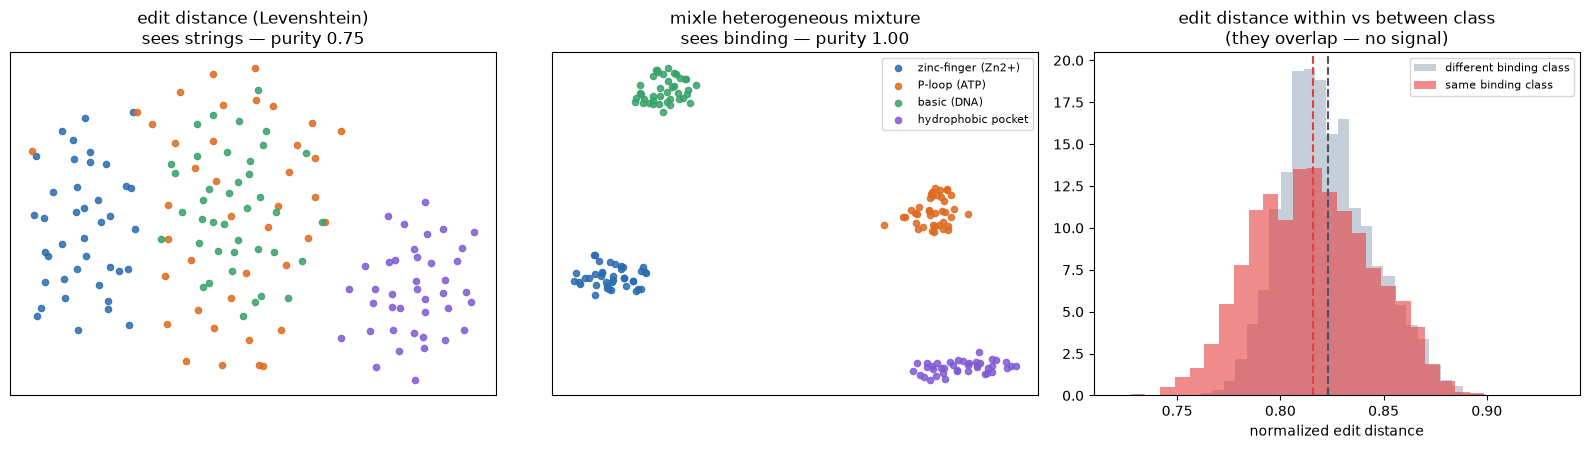

edit-distance embedding purity : 0.75
mixle embedding purity         : 1.00
edit distance  same-class 0.816  vs  different-class 0.823  (a 0.9% gap)


In [2]:
from rapidfuzz.distance import Levenshtein
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

def knn_purity(Y, lab, k=10):
    idx = NearestNeighbors(n_neighbors=k + 1).fit(Y).kneighbors(Y, return_distance=False)[:, 1:]
    return float(np.mean([(lab[idx[i]] == lab[i]).mean() for i in range(len(lab))]))

N = len(seqs)
D = np.zeros((N, N))                                   # pairwise normalized edit distance
for i in range(N):
    for j in range(i + 1, N):
        D[i, j] = D[j, i] = Levenshtein.normalized_distance(seqs[i], seqs[j])

Y_edit = TSNE(metric='precomputed', init='random', perplexity=20, random_state=0).fit_transform(D)
Y_mixle = htsne(proteins, seed=1, perplexity=20, out=io.StringIO())

within  = D[np.triu(binds[:, None] == binds[None, :], 1)]
between = D[np.triu(binds[:, None] != binds[None, :], 1)]

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for a, Y, title in [(ax[0], Y_edit, 'edit distance (Levenshtein)\nsees strings'),
                    (ax[1], Y_mixle, 'mixle heterogeneous mixture\nsees binding')]:
    for k, name in enumerate(bind_names):
        m = binds == k
        a.scatter(Y[m, 0], Y[m, 1], s=20, color=COLORS[k], label=name, alpha=0.85)
    a.set_title('%s — purity %.2f' % (title, knn_purity(Y, binds))); a.set_xticks([]); a.set_yticks([])
ax[1].legend(fontsize=8, loc='best')
ax[2].hist(between, bins=30, alpha=0.6, color='#a0aec0', density=True, label='different binding class')
ax[2].hist(within,  bins=30, alpha=0.6, color='#e53e3e', density=True, label='same binding class')
ax[2].axvline(within.mean(), color='#e53e3e', ls='--'); ax[2].axvline(between.mean(), color='#4a5568', ls='--')
ax[2].set_title('edit distance within vs between class\n(they overlap — no signal)')
ax[2].set_xlabel('normalized edit distance'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print('edit-distance embedding purity : %.2f' % knn_purity(Y_edit, binds))
print('mixle embedding purity         : %.2f' % knn_purity(Y_mixle, binds))
print('edit distance  same-class %.3f  vs  different-class %.3f  (a %.1f%% gap)'
      % (within.mean(), between.mean(), 100 * (between.mean() - within.mean()) / between.mean()))

Proteins that bind the **same** ligand are barely more edit-similar than proteins that bind
**different** ligands — the two histograms sit almost on top of each other. Edit distance spends all
its resolution on the ~99% of the sequence that is binding-irrelevant, so its map only partly recovers
the classes. The heterogeneous mixture ignores position and reads the binding chemistry directly, and
the classes separate cleanly. *Binding function is not sequence identity* — and choosing the right
representation, not a fancier embedder, is what makes it visible.

## 2. `humap` and the affinity metric

The same records embed under a UMAP-style objective, and `affinity=` selects how similarity is measured.

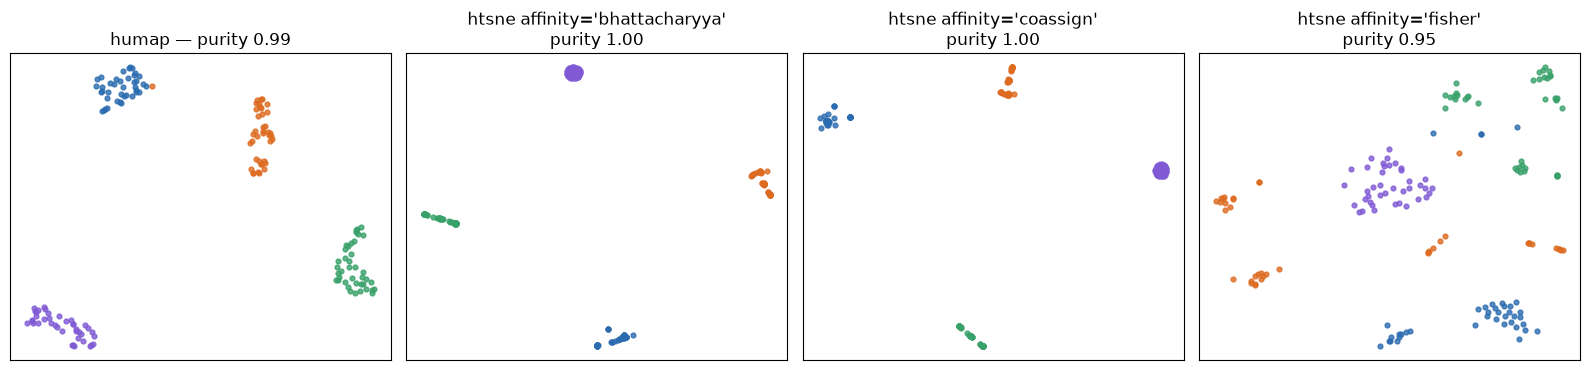

In [3]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.8))
Yh = humap(proteins, seed=1, n_neighbors=15, out=io.StringIO())
for k, name in enumerate(bind_names):
    m = binds == k
    ax[0].scatter(Yh[m, 0], Yh[m, 1], s=12, color=COLORS[k], alpha=0.8)
ax[0].set_title('humap — purity %.2f' % knn_purity(Yh, binds)); ax[0].set_xticks([]); ax[0].set_yticks([])
for a, aff in zip(ax[1:], ['bhattacharyya', 'coassign', 'fisher']):
    Y = htsne(proteins, seed=1, perplexity=20, affinity=aff, out=io.StringIO())
    for k in range(len(bind_names)):
        m = binds == k
        a.scatter(Y[m, 0], Y[m, 1], s=12, color=COLORS[k], alpha=0.8)
    a.set_title("htsne affinity='%s'\npurity %.2f" % (aff, knn_purity(Y, binds))); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 3. A binding-chemistry axis with `goals` (new in mixle 0.7.0)

An embedding's axes are arbitrary. `AxisAlign` (a `goal`) rotates the layout so a quantity you care
about reads along an axis — here the **x-axis becomes metal-coordination potential**, so the map turns
into a left-to-right gradient of "how well could this protein cage a metal ion?", with the zinc fingers
driven to one side. We also fit an explicit mixture to supply `embedding_health` below.

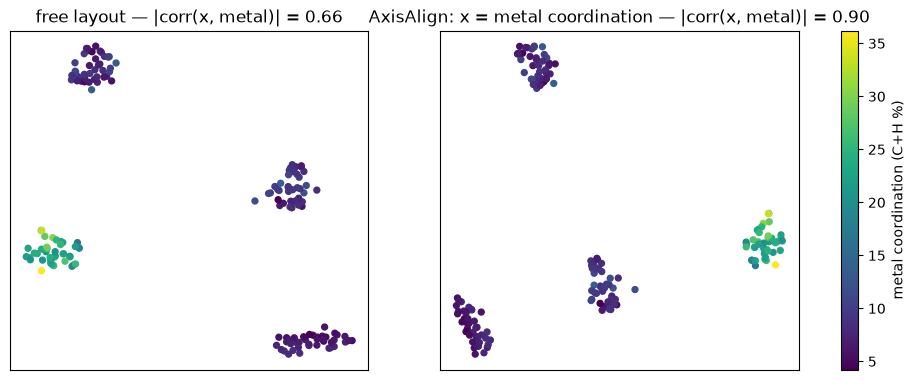

x-axis / metal-coordination correlation: free 0.66 -> AxisAlign 0.90


In [4]:
from mixle.stats import (GaussianEstimator, CategoricalEstimator, PoissonEstimator, CompositeEstimator, MixtureEstimator)
from mixle.inference.estimation import optimize
from mixle.utils.hvis import AxisAlign

record_est = CompositeEstimator((GaussianEstimator(), GaussianEstimator(), GaussianEstimator(),
                                 PoissonEstimator(), CategoricalEstimator()))
mix = optimize(proteins, MixtureEstimator([record_est] * 4), max_its=50, rng=np.random.RandomState(0), out=io.StringIO())

metal = np.array([p[0] for p in proteins])
free = htsne(proteins, seed=1, perplexity=20, out=io.StringIO())
axed = htsne(proteins, seed=1, perplexity=20, goals=[AxisAlign(metal.tolist(), axis=0, weight=0.6)], out=io.StringIO())
corr = lambda Y: abs(np.corrcoef(Y[:, 0], metal)[0, 1])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for a, Y, t in [(ax[0], free, 'free layout'), (ax[1], axed, 'AxisAlign: x = metal coordination')]:
    sc = a.scatter(Y[:, 0], Y[:, 1], c=metal, cmap='viridis', s=18)
    a.set_title('%s — |corr(x, metal)| = %.2f' % (t, corr(Y))); a.set_xticks([]); a.set_yticks([])
fig.colorbar(sc, ax=ax, fraction=0.025, label='metal coordination (C+H %)'); plt.show()
print('x-axis / metal-coordination correlation: free %.2f -> AxisAlign %.2f' % (corr(free), corr(axed)))

## 4. Is the binding map trustworthy? `embedding_health` (new in mixle 0.7.0)

`embedding_health` scores a layout against the mixture's own affinity — **trustworthiness** and
**continuity** — so a misleading binding map is rejected by number. We score a well-optimized map, an
under-optimized one, and a random scatter.

In [5]:
from mixle.utils.hvis import embedding_health

good = htsne(proteins, seed=1, perplexity=20, mix_model=mix, max_its=1000, out=io.StringIO())
undercooked = htsne(proteins, seed=1, perplexity=20, mix_model=mix, max_its=5, out=io.StringIO())
scramble = np.random.RandomState(0).randn(len(proteins), 2)
for name, Y in [('well-optimized', good), ('under-optimized (5 its)', undercooked), ('random scatter', scramble)]:
    h = embedding_health(Y, mix, proteins)
    issues = '; '.join(h['diagnosis']) if h['diagnosis'] else 'no issues flagged'
    print('%-24s trust=%.3f  cont=%.3f  -- %s' % (name, h['trustworthiness'], h['continuity'], issues[:84]))

well-optimized           trust=0.985  cont=0.986  -- no issues flagged
under-optimized (5 its)  trust=0.509  cont=0.456  -- trustworthiness 0.51: the map shows neighbor pairs the model does not support -- tre
random scatter           trust=0.501  cont=0.517  -- trustworthiness 0.50: the map shows neighbor pairs the model does not support -- tre


## What 0.7.0 gives you here

* **Representation beats embedder.** Edit distance — global string similarity — barely tells binding
  classes apart (same-class and different-class distances overlap), so even a good embedder only partly
  recovers them. A **heterogeneous mixture** over binding-relevant features (metal coordination, basic
  fraction, hydropathy, length, motif) recovers *what each protein binds* at near-perfect purity.
* **`goals`** (`AxisAlign`) give the map a **meaningful binding axis** — the x-axis reads
  metal-coordination potential (correlation lifted from incidental to ~0.9).
* **`embedding_health`** turns "looks clustered" into a **number** — the good binding map scores ~0.98,
  an under-optimized or random one ~0.5, with a diagnosis of why.

Swap the synthetic sequences for a real FASTA (curated zinc-fingers, P-loop NTPases, transcription
factors) and the same pipeline maps them by binding — and, unlike an alignment score, tells you whether
to trust the map.